# Controlled Synthetic Study of Spatiotemporal Traffic Forecasting Models

## 1. Purpose of This Notebook

This notebook contains a controlled, simulation-based evaluation of the forecasting models studied in our PeMS work. The goal is **not** to replace the real-data results, but to provide a controlled testbed where we can vary the data-generating process and observe how each model responds. By doing so, we can move beyond statements of the form *"model A beat model B on this dataset"* toward statements of the form *"model A beats model B when condition X holds, and we can verify that condition X is present in the real-world data."*

In our PeMS experiments, we observed three patterns that are difficult to interpret on real data alone:

1. Random Forest achieved the lowest MAE under clean, full-information conditions, despite ignoring spatial structure entirely.
2. Under simulated sensor outages, GraphWaveNet–LSTM outperformed the proposed GraphWaveNet–GRU–LSTM, while GraphWaveNet–GRU performed substantially worse than either.
3. The proposed model improved over the base GraphWaveNet at every horizon, but the magnitude of the improvement was modest at long horizons (≈3.4% at 72 h).

Each of these observations admits multiple explanations, and real data does not let us isolate them. For example, RF may be winning because (a) the spatial coupling between stations is genuinely weak in District 3, (b) our 24-hour input window prevents graph models from accessing weekly history that RF can engineer as features, (c) the training-set size is too small for graph models to learn well, or (d) some combination of these. The simulation study is designed to disentangle these explanations.

## 2. Research Questions

We organize the simulation study around five research questions, each addressed by a dedicated experiment. The first three are required for the publication-grade version of this study; the remaining two strengthen the conclusions but can be reduced in scope if computational budget is constrained.

**RQ1 — Spatial coupling.** How does the relative performance of feature-based models (Random Forest), non-graph deep models, and graph-based models depend on the strength of spatial coupling between stations? We hypothesize that there exists a coupling threshold below which graph methods cannot outperform feature-based baselines, and that District 3 falls near or below this threshold.

**RQ2 — Outage typology.** Real sensor failures are rarely independent across stations or windows. They tend to be spatially clustered (an entire corridor goes dark when a roadside cabinet fails), temporally extended (a station is offline for days, not hours), or intermittent within a window. Are the robustness conclusions drawn from random per-window masking representative of more realistic failure modes?

**RQ3 — Training-seed variance.** The robustness comparisons in our PeMS study used a single trained checkpoint per architecture, with variance reported only across mask seeds. Are the observed differences between graph variants (in particular the gap between GraphWaveNet–GRU and GraphWaveNet–LSTM under outage) statistically meaningful, or are they within the range of training-seed noise?

**RQ4 — Input-window length.** Does the gap between Random Forest and graph models close when graph models are given access to longer input histories that include weekly periodic structure?

**RQ5 — Horizon-refinement interaction.** Does the benefit of stacked GRU–LSTM refinement grow with forecast horizon, as the architecture motivation in the paper suggests, or is it horizon-independent?

## 3. Approach Overview

We construct a synthetic traffic generator with explicit, controllable knobs for the quantities the research questions ask about. The generator produces hourly flow series on a graph of sensors arranged along corridors, in the same NumPy format as our real-data pipeline (`X`, `Y`, `A`, `train_starts`, `val_starts`, `test_starts`, etc.), so that **the existing model code runs on simulated data without modification**.

For each experiment, we vary one knob of the generator while holding the others fixed at calibrated defaults, train each model on the resulting dataset, and evaluate on a held-out test split. All splits use the same target-window-contained logic as the PeMS pipeline to prevent leakage.

The models evaluated are:

- Elastic Net (regularized linear regression baseline)
- Random Forest (tree ensemble baseline, per-station)
- LSTM (non-graph deep baseline)
- CNN-GRU-LSTM (non-graph hybrid baseline)
- GraphWaveNet (graph baseline)
- GraphWaveNet-GRU
- GraphWaveNet-LSTM
- GraphWaveNet-GRU-LSTM (proposed)

Hyperparameters for each model are fixed across experiments at the values used in the PeMS study. This is a deliberate choice: re-tuning per experiment would conflate architectural advantages with hyperparameter-search advantages.

## 4. Synthetic Data-Generating Process

We define a controllable synthetic flow generator $\mathcal{G}(\theta)$ where $\theta$ is the vector of generation parameters. The graph $G = (V, E)$ has $N$ nodes arranged along $C$ corridors, mimicking the freeway-corridor topology of PeMS. Each node $n$ is connected to its $K$ nearest upstream and $K$ nearest downstream neighbors on the same corridor, with edge weights given by a Gaussian kernel of post-mile distance, exactly as in the PeMS adjacency construction.

For each node $n \in \{1, \dots, N\}$ and each hour $t \in \{1, \dots, T\}$, the observed flow is generated in three additive components: a **deterministic seasonal baseline**, a **spatial propagation term** that mixes in delayed signals from upstream neighbors, and a **stochastic component** that includes both station-specific noise and discrete event perturbations.

### 4.1 Seasonal Baseline

Each station has its own intercept and amplitude, drawn at generation time and held fixed across the study period:

$$
b_n(t) = a_n + \beta_n^{\text{daily}} \sin\!\left(\tfrac{2\pi t}{24} + \phi_n^d\right) + \beta_n^{\text{weekly}} \sin\!\left(\tfrac{2\pi t}{168} + \phi_n^w\right)
$$

Here $a_n$ is the station's mean flow level, $\beta_n^{\text{daily}}$ and $\beta_n^{\text{weekly}}$ are amplitudes for the 24-hour and 168-hour cycles, and $\phi_n^d, \phi_n^w$ are random phase offsets that produce realistic station heterogeneity. All four are sampled once from prior distributions calibrated to PeMS-like ranges (mean flow ≈ 200 veh/h, daily amplitude ≈ 150 veh/h, weekly amplitude ≈ 50 veh/h).

### 4.2 Spatial Propagation

To inject controllable spatial dependence, we mix each node's baseline with a delayed weighted sum of its upstream neighbors:

$$
s_n(t) = (1 - \alpha)\, b_n(t) + \alpha \sum_{m \in \mathcal{U}(n)} w_{nm}\, b_m(t - \tau_{nm})
$$

where $\mathcal{U}(n)$ is the set of upstream neighbors of $n$, $w_{nm}$ are normalized edge weights ($\sum_m w_{nm} = 1$), $\tau_{nm}$ is an integer hour-lag drawn from $\{1, 2, 3\}$ to simulate physical propagation time between sensors, and $\alpha \in [0, 1]$ is the **spatial coupling parameter** ,the central knob of the study.

The interpretation of $\alpha$ is direct: at $\alpha = 0$, every station's signal is independent of every other station's, and there is no information for graph methods to exploit. At $\alpha = 1$, each station's signal is entirely determined by its upstream neighbors, and graph methods should have a maximal advantage.

### 4.3 Events and Noise

Real traffic exhibits discrete shocks; incidents, construction, weather, that propagate downstream. We inject events at random times by selecting a random origin node and a random duration $d \sim \text{Uniform}(2, 8)$ hours, then applying a multiplicative reduction $\eta \sim \text{Uniform}(0.3, 0.7)$ to the origin and its $K$-hop downstream descendants for the duration. Events do not propagate through $\alpha$; they are structurally separate so that the same event sequence can be reused across $\alpha$ values for a controlled comparison.

Finally, we add station-specific Gaussian noise:

$$
y_n(t) = \max\!\big(0,\ s_n(t) + e_n(t) + \varepsilon_n(t)\big), \qquad \varepsilon_n(t) \sim \mathcal{N}(0, \sigma_n^2)
$$

The non-negativity clip enforces the physical constraint that flow cannot be negative. The noise standard deviation $\sigma_n$ is set as a fraction (default 10%) of the station's mean flow.

### 4.4 Generator Parameters and Defaults

The generator has the following knobs, with default values used unless explicitly varied by an experiment:

| Symbol | Meaning | Default |
|---|---|---|
| $N$ | Number of nodes | 500 |
| $C$ | Number of corridors | 10 |
| $T$ | Number of hourly timestamps | 2,208 (≈ 92 days) |
| $K$ | Neighbors per side in adjacency | 2 |
| $\alpha$ | Spatial coupling strength | 0.5 |
| Daily amplitude | Mean of $\beta_n^{\text{daily}}$ | 150 |
| Weekly amplitude | Mean of $\beta_n^{\text{weekly}}$ | 50 |
| Noise level | $\sigma_n / a_n$ | 0.10 |
| Event rate | Events per node per study period | 0.5 |

The default $T$ matches the PeMS study period exactly (2024-10-01 to 2024-12-31, hourly). Choosing $N = 500$ rather than ≈1800 is a deliberate compromise between realism and iteration speed; a small-scale pilot at $N = 50$ is run first to validate that experiments produce sensible patterns before committing to the full-scale runs.

### 4.5 Assumptions and Limitations of the Generator

We make the following assumptions explicit so they can be examined in the discussion:

1. **Linear-additive structure.** Real traffic interactions are non-linear (congestion regimes, capacity constraints). The generator captures linear propagation only. This is conservative for graph methods — if anything, real non-linearities should *increase* the value of expressive non-linear models.
2. **Static graph topology.** The corridor structure does not change over time. PeMS is also effectively static at the timescales we consider.
3. **Stationary parameters.** Station amplitudes and means do not drift across the study period. Holiday weeks in PeMS do show drift; this is a limitation we acknowledge.
4. **No reverse propagation.** We model only upstream-to-downstream flow propagation. Backward propagation of congestion is real but harder to calibrate; including it would not change the conclusions of the spatial-coupling experiment.

These assumptions mean the generator is a **simplified surrogate** for real traffic, not a digital twin. Its purpose is to provide controlled conditions under which model behavior can be isolated, not to replicate PeMS dynamics.

## 5. Experimental Design

Each of the five experiments follows the same protocol. We generate data with a fixed random seed for the data-generating process, train each model with three independent training seeds (for reasons established by RQ3), and report mean ± std MAE across training seeds at horizons $h \in \{12, 24, 48, 72\}$ hours. Where an experiment varies a parameter (e.g. $\alpha$ in RQ1), we hold all other generator parameters at their defaults.

The protocol is summarized below. Implementation details for each experiment are documented in the corresponding section of this notebook.

| Experiment | Parameter Varied | Values | Models Evaluated |
|---|---|---|---|
| RQ1 | $\alpha$ (spatial coupling) | {0.0, 0.2, 0.5, 0.8} | All 8 |
| RQ2 | Outage type | {random, clustered, extended, intermittent, adversarial} | RF + 4 graph variants |
| RQ3 | Training seed | 5 seeds | 4 graph variants |
| RQ4 | Input length $L$ | {12, 24, 48, 168} | RF + 4 graph variants |
| RQ5 | Forecast horizon $h$ × architecture | {12, 24, 48, 72} × 4 variants | 4 graph variants |

All experiments share a common evaluation harness defined later in this notebook. Results are written to a structured `artifacts/sim/` directory, with each run producing a JSON metadata file, a metrics CSV, and a checkpoint, mirroring the artifact structure of the PeMS pipeline.

## 6. What This Study Cannot Establish

It is worth being explicit about the limits of what controlled simulation can tell us. The simulation study can establish that the proposed model is competitive **under conditions described by our generator's parameter ranges**. It cannot establish that those conditions are universal, nor that they exhaust the relevant axes of variation in real data. In particular, the simulation will not capture: heterogeneous sensor reliability characteristics, weather-induced demand shifts, holiday and seasonal regime changes, or driver behavioral responses to congestion. The validity of generalizing simulation conclusions to PeMS rests on the bridge experiment in Section X (to be added), which checks whether the spatial-coupling and other relevant parameters of the simulated regime where the proposed model wins are consistent with values estimated from PeMS data.

## 7. Notebook Organization

The remainder of this notebook is organized as follows. Section 8 implements the synthetic generator. Section 9 implements the evaluation harness and shared utilities. Sections 10–14 contain Experiments 1–5 corresponding to RQ1–RQ5. Section 15 aggregates results across experiments and discusses bridge inferences to PeMS. Section 16 produces the publication-ready figures and tables.

# 8. Implementation: Synthetic Traffic Generator
 
This section implements the data-generating process specified in Section 4.
The generator is structured as a small set of composable functions, each
corresponding to one component of the model:
 
1. `build_corridor_graph` — lay out nodes on corridors and build the
   symmetric K-nearest-neighbor adjacency matrix used by the graph models.
2. `build_propagation_structure` — for each node, identify which upstream
   neighbors influence it and with what lag and weight. This is a
   *directed* propagation structure that is structurally separate from the
   symmetric adjacency `A` used by the models. Keeping these two structures
   separate is intentional: it ensures models cannot trivially recover the
   ground truth by inverting the adjacency they are trained on.
3. `build_baseline` — generate the per-station deterministic seasonal
   baseline $b_n(t)$ with daily and weekly periodic components and
   station-specific phase, amplitude, and intercept.
4. `apply_spatial_propagation` — mix each station's baseline with delayed
   contributions from upstream neighbors, controlled by $\\alpha$.
5. `inject_events` — apply discrete multiplicative reductions at random
   origins, propagated $h$ hops downstream for random durations.
6. `add_noise` — add station-scaled Gaussian noise and clip at zero to
   enforce physical non-negativity of flow.
 
The top-level function `generate(cfg)` runs the full pipeline and returns a
dictionary of artifacts. The output dictionary contains `flow`, `speed`,
`A`, `post_miles`, `corridor_id`, `timestamps`, and a copy of the config.
This matches the structure of the PeMS pipeline, so downstream model code
runs without modification.
 
**Reproducibility.** Each component uses a deterministic seed offset from
the master `cfg.seed`, so identical configs produce identical outputs.
Different components (graph, baseline, events, noise) use distinct seeds
so that, for example, two configs that differ only in `alpha` share the
same graph topology and event sequence — only the propagation differs.
This is what makes the $\\alpha$ sweep in Experiment 1 a clean controlled
comparison rather than a comparison of confounded random draws.
 
**Speed feature.** Our PeMS pipeline uses both flow and speed as input
features. To preserve the same input dimensionality on simulated data, we
derive a synthetic speed signal that is anti-correlated with flow,
following the standard fundamental-diagram intuition: speed decreases as
flow rises above the station mean. This is a *deliberately simple*
construction; we do not claim it captures real speed-flow dynamics, only
that it gives the models a second feature with a plausible relationship
to the first.
 
**Pilot scale.** All cells in Section 8 run at a pilot scale of $N=50$,
$T=14 \\times 24$ for fast iteration. Section 9 onward runs at the full
publication scale of $N=500$, $T=2208$

flow shape:    (336, 50)
flow stats:    mean=216.0, std=87.6
adjacency nnz: 220
corridor sizes:[10, 10, 10, 10, 10]
Generator ready.


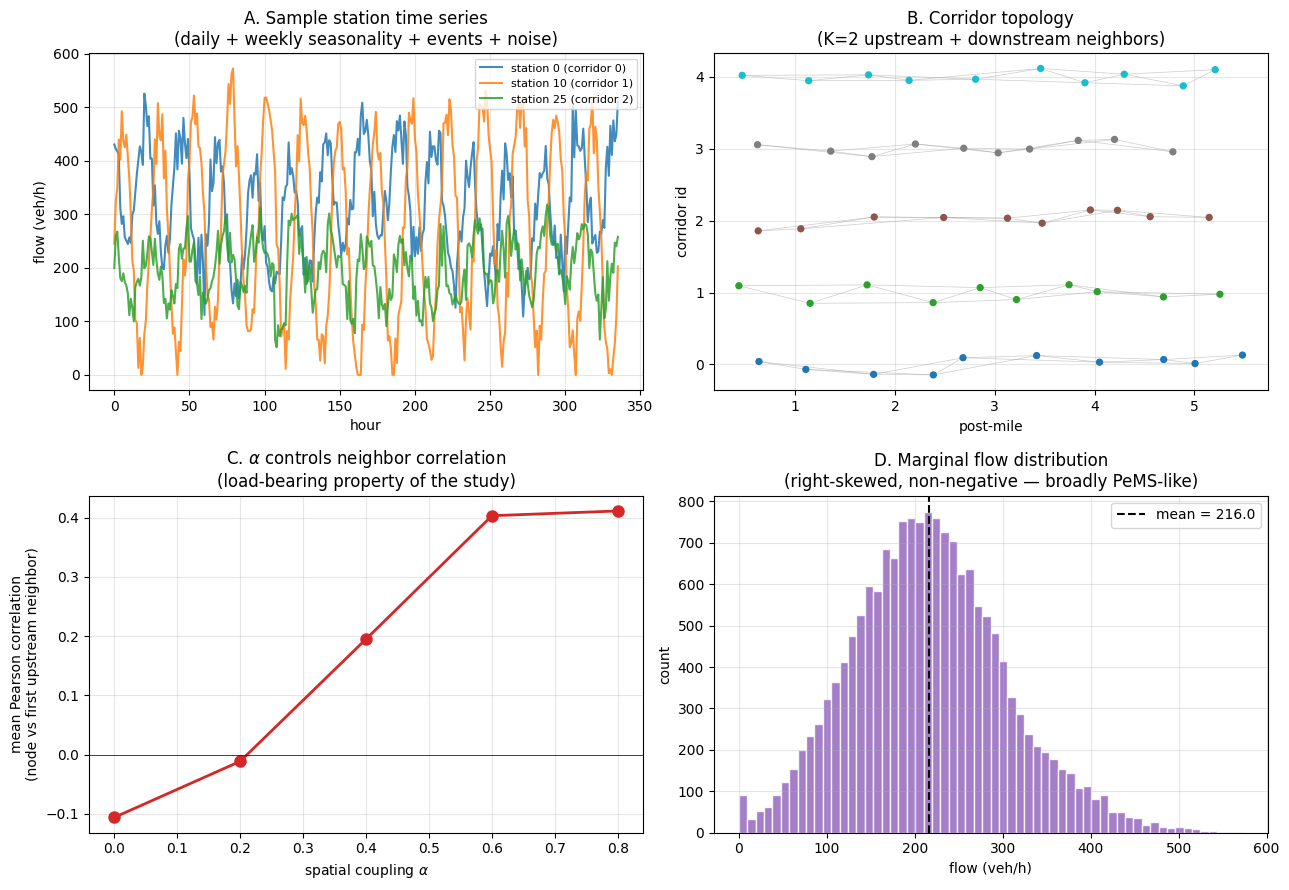


=== alpha sweep correlation values ===
  alpha = 0.0: corr = -0.106
  alpha = 0.2: corr = -0.011
  alpha = 0.4: corr = +0.195
  alpha = 0.6: corr = +0.404
  alpha = 0.8: corr = +0.412


In [1]:
# ============================================================================
# The generator)
# ============================================================================
 
import numpy as np
import pandas as pd
from dataclasses import dataclass, asdict
from typing import Optional
 
 
@dataclass
class GeneratorConfig:
    """All knobs of the synthetic data-generating process."""
    # Graph topology
    num_nodes: int = 500
    num_corridors: int = 10
    neighbors_per_side: int = 2
    sigma_distance: float = 1.5
    post_mile_spacing: float = 0.5
 
    # Time
    num_hours: int = 2208
    start_timestamp: str = "2024-10-01 00:00"
 
    # Seasonal baseline
    mean_flow_loc: float = 200.0
    mean_flow_scale: float = 80.0
    daily_amp_loc: float = 150.0
    daily_amp_scale: float = 40.0
    weekly_amp_loc: float = 50.0
    weekly_amp_scale: float = 15.0
 
    # Spatial coupling
    alpha: float = 0.5
    propagation_lag_min: int = 1
    propagation_lag_max: int = 3
 
    # Events
    events_per_node: float = 0.5
    event_duration_min: int = 2
    event_duration_max: int = 8
    event_strength_min: float = 0.3
    event_strength_max: float = 0.7
    event_downstream_hops: int = 2
 
    # Noise
    noise_relative: float = 0.10
 
    # Reproducibility
    seed: int = 42
 
 
def build_corridor_graph(cfg):
    rng = np.random.default_rng(cfg.seed)
    N, C = cfg.num_nodes, cfg.num_corridors
    base, extras = N // C, N - (N // C) * C
    sizes = [base + (1 if i < extras else 0) for i in range(C)]
    corridor_id = np.concatenate(
        [np.full(s, c, dtype=np.int32) for c, s in enumerate(sizes)]
    )
    post_miles = np.zeros(N, dtype=np.float32)
    offset = 0
    for c, s in enumerate(sizes):
        gaps = rng.uniform(0.5 * cfg.post_mile_spacing,
                           1.5 * cfg.post_mile_spacing, size=s)
        post_miles[offset:offset + s] = np.cumsum(gaps).astype(np.float32)
        offset += s
    A = np.zeros((N, N), dtype=np.float32)
    K, sigma = cfg.neighbors_per_side, cfg.sigma_distance
    for c in range(C):
        idx = np.where(corridor_id == c)[0]
        order = idx[np.argsort(post_miles[idx])]
        for k_pos, i in enumerate(order):
            for off_k in range(1, K + 1):
                if k_pos + off_k < len(order):
                    j = order[k_pos + off_k]
                    d = abs(post_miles[i] - post_miles[j])
                    A[i, j] = max(A[i, j], float(np.exp(-(d**2) / (sigma**2))))
                if k_pos - off_k >= 0:
                    j = order[k_pos - off_k]
                    d = abs(post_miles[i] - post_miles[j])
                    A[i, j] = max(A[i, j], float(np.exp(-(d**2) / (sigma**2))))
    A = np.maximum(A, A.T)
    np.fill_diagonal(A, 1.0)
    return A, post_miles, corridor_id
 
 
def build_propagation_structure(cfg, A, corridor_id, post_miles):
    rng = np.random.default_rng(cfg.seed + 1)
    N, K = cfg.num_nodes, cfg.neighbors_per_side
    upstream = [[] for _ in range(N)]
    for c in range(cfg.num_corridors):
        idx = np.where(corridor_id == c)[0]
        order = idx[np.argsort(post_miles[idx])]
        for k_pos, n in enumerate(order):
            ups = []
            for off_k in range(1, K + 1):
                if k_pos - off_k >= 0:
                    m = order[k_pos - off_k]
                    d = abs(post_miles[n] - post_miles[m])
                    w = float(np.exp(-(d**2) / (cfg.sigma_distance**2)))
                    lag = int(rng.integers(cfg.propagation_lag_min,
                                           cfg.propagation_lag_max + 1))
                    ups.append((int(m), w, lag))
            if ups:
                total = sum(w for _, w, _ in ups)
                ups = [(m, w / total, lag) for m, w, lag in ups]
            upstream[n] = ups
    return upstream
 
 
def build_baseline(cfg):
    rng = np.random.default_rng(cfg.seed + 2)
    T, N = cfg.num_hours, cfg.num_nodes
    a = np.maximum(rng.normal(cfg.mean_flow_loc, cfg.mean_flow_scale, N),
                   20.0).astype(np.float32)
    beta_d = np.maximum(rng.normal(cfg.daily_amp_loc, cfg.daily_amp_scale, N),
                        10.0).astype(np.float32)
    beta_w = np.maximum(rng.normal(cfg.weekly_amp_loc, cfg.weekly_amp_scale, N),
                        5.0).astype(np.float32)
    phi_d = rng.uniform(0, 2 * np.pi, N).astype(np.float32)
    phi_w = rng.uniform(0, 2 * np.pi, N).astype(np.float32)
    t = np.arange(T, dtype=np.float32)
    daily = np.sin(2 * np.pi * t[:, None] / 24.0 + phi_d[None, :])
    weekly = np.sin(2 * np.pi * t[:, None] / 168.0 + phi_w[None, :])
    B = a[None, :] + beta_d[None, :] * daily + beta_w[None, :] * weekly
    return B.astype(np.float32), a
 
 
def apply_spatial_propagation(B, upstream, alpha):
    T, N = B.shape
    S = B.copy()
    if alpha <= 0:
        return S
    for n in range(N):
        ups = upstream[n]
        if not ups:
            continue
        mix = np.zeros(T, dtype=np.float32)
        for m, w, lag in ups:
            shifted = np.empty(T, dtype=np.float32)
            shifted[:lag] = B[:lag, m]
            shifted[lag:] = B[: T - lag, m]
            mix += w * shifted
        S[:, n] = (1.0 - alpha) * B[:, n] + alpha * mix
    return S
 
 
def downstream_descendants(origin, cfg, corridor_id, post_miles, hops):
    c = corridor_id[origin]
    idx = np.where(corridor_id == c)[0]
    order = idx[np.argsort(post_miles[idx])]
    pos = int(np.where(order == origin)[0][0])
    end = min(len(order), pos + hops + 1)
    return order[pos:end].tolist()
 
 
def inject_events(S, cfg, corridor_id, post_miles):
    rng = np.random.default_rng(cfg.seed + 3)
    T, N = S.shape
    Y = S.copy()
    n_events = int(round(cfg.events_per_node * N))
    for _ in range(n_events):
        origin = int(rng.integers(0, N))
        start = int(rng.integers(0, T))
        duration = int(rng.integers(cfg.event_duration_min,
                                    cfg.event_duration_max + 1))
        strength = float(rng.uniform(cfg.event_strength_min,
                                     cfg.event_strength_max))
        end = min(T, start + duration)
        affected = downstream_descendants(origin, cfg, corridor_id, post_miles,
                                          cfg.event_downstream_hops)
        Y[start:end, affected] *= strength
    return Y
 
 
def add_noise(Y, cfg, station_means):
    rng = np.random.default_rng(cfg.seed + 4)
    sigma = cfg.noise_relative * station_means
    eps = rng.normal(0, 1, size=Y.shape).astype(np.float32) * sigma[None, :]
    return np.maximum(0.0, Y + eps).astype(np.float32)
 
 
def generate(cfg=None):
    if cfg is None:
        cfg = GeneratorConfig()
    A, post_miles, corridor_id = build_corridor_graph(cfg)
    upstream = build_propagation_structure(cfg, A, corridor_id, post_miles)
    B, station_means = build_baseline(cfg)
    S = apply_spatial_propagation(B, upstream, cfg.alpha)
    Y = inject_events(S, cfg, corridor_id, post_miles)
    flow = add_noise(Y, cfg, station_means)
    base_speed = 65.0
    k = 30.0 / np.maximum(station_means, 1.0)
    flow_dev = flow - station_means[None, :]
    speed = base_speed - k[None, :] * flow_dev
    rng = np.random.default_rng(cfg.seed + 5)
    speed = speed + rng.normal(0, 1.5, size=speed.shape).astype(np.float32)
    speed = np.clip(speed, 10.0, 80.0).astype(np.float32)
    timestamps = pd.date_range(start=cfg.start_timestamp,
                               periods=cfg.num_hours, freq="h")
    return dict(flow=flow, speed=speed, A=A, post_miles=post_miles,
                corridor_id=corridor_id, timestamps=timestamps,
                config=asdict(cfg))
 
 
# Quick smoke test (will print sane numbers if everything works)
_cfg = GeneratorConfig(num_nodes=50, num_corridors=5, num_hours=24 * 14)
_out = generate(_cfg)
print(f"flow shape:    {_out['flow'].shape}")
print(f"flow stats:    mean={_out['flow'].mean():.1f}, "
      f"std={_out['flow'].std():.1f}")
print(f"adjacency nnz: {int((_out['A'] > 0).sum())}")
print(f"corridor sizes:{np.bincount(_out['corridor_id']).tolist()}")
print("Generator ready.")
 
 
# ============================================================================
# CELL 8.3 — CODE (validation plot)
# Paste the entire block below into a single code cell. Run this AFTER cell
# 8.2 has been executed (it depends on the functions defined there).
# ============================================================================
 
import matplotlib.pyplot as plt
 
# Pilot run for visualization
cfg_vis = GeneratorConfig(num_nodes=50, num_corridors=5, num_hours=24 * 14)
out_vis = generate(cfg_vis)
 
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
 
# Panel A: time series for 3 stations from different corridors
ax = axes[0, 0]
hours = np.arange(out_vis['flow'].shape[0])
for n, color in zip([0, 10, 25], ['C0', 'C1', 'C2']):
    ax.plot(hours, out_vis['flow'][:, n], color=color, alpha=0.85,
            label=f"station {n} (corridor {out_vis['corridor_id'][n]})")
ax.set_xlabel("hour")
ax.set_ylabel("flow (veh/h)")
ax.set_title("A. Sample station time series\n"
             "(daily + weekly seasonality + events + noise)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
 
# Panel B: corridor topology with adjacency edges
ax = axes[0, 1]
N = cfg_vis.num_nodes
xs = out_vis['post_miles']
ys = out_vis['corridor_id'].astype(float)
ys = ys + np.random.default_rng(0).uniform(-0.15, 0.15, size=N)
ax.scatter(xs, ys, s=18, c=out_vis['corridor_id'], cmap='tab10', zorder=3)
A_vis = out_vis['A']
for i in range(N):
    for j in range(i + 1, N):
        if A_vis[i, j] > 0 and out_vis['corridor_id'][i] == out_vis['corridor_id'][j]:
            ax.plot([xs[i], xs[j]], [ys[i], ys[j]],
                    color='gray', linewidth=0.5, alpha=0.4, zorder=1)
ax.set_xlabel("post-mile")
ax.set_ylabel("corridor id")
ax.set_title("B. Corridor topology\n"
             "(K=2 upstream + downstream neighbors)")
ax.grid(alpha=0.3)
 
# Panel C: alpha sweep — load-bearing property
ax = axes[1, 0]
alphas = [0.0, 0.2, 0.4, 0.6, 0.8]
mean_corrs = []
for a in alphas:
    cfg_a = GeneratorConfig(num_nodes=50, num_corridors=5, num_hours=24 * 14,
                            alpha=a, events_per_node=0.0, noise_relative=0.05)
    out_a = generate(cfg_a)
    upstream = build_propagation_structure(cfg_a, out_a['A'],
                                           out_a['corridor_id'],
                                           out_a['post_miles'])
    corrs = []
    for n in range(cfg_a.num_nodes):
        if upstream[n]:
            m = upstream[n][0][0]
            corrs.append(np.corrcoef(out_a['flow'][:, n], out_a['flow'][:, m])[0, 1])
    mean_corrs.append(np.mean(corrs))
ax.plot(alphas, mean_corrs, 'o-', linewidth=2, markersize=8, color='C3')
ax.set_xlabel(r"spatial coupling $\alpha$")
ax.set_ylabel("mean Pearson correlation\n(node vs first upstream neighbor)")
ax.set_title(r"C. $\alpha$ controls neighbor correlation"
             "\n(load-bearing property of the study)")
ax.grid(alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
 
# Panel D: marginal flow distribution
ax = axes[1, 1]
ax.hist(out_vis['flow'].flatten(), bins=60, color='C4',
        edgecolor='white', alpha=0.85)
ax.axvline(out_vis['flow'].mean(), color='black', linestyle='--',
           label=f"mean = {out_vis['flow'].mean():.1f}")
ax.set_xlabel("flow (veh/h)")
ax.set_ylabel("count")
ax.set_title("D. Marginal flow distribution\n"
             "(right-skewed, non-negative — broadly PeMS-like)")
ax.legend()
ax.grid(alpha=0.3)
 
plt.tight_layout()
plt.show()
 
print("\n=== alpha sweep correlation values ===")
for a, c in zip(alphas, mean_corrs):
    print(f"  alpha = {a}: corr = {c:+.3f}")
 

## 9. Evaluation Harness
 
The five experiments planned in Section 2 share a common evaluation pipeline:
generate data, build sliding-window splits, train a model, evaluate at
horizons 12 / 24 / 48 / 72, save results. Implementing this once in a
shared harness rather than re-coding it per experiment serves two purposes.
First, it ensures every experiment uses identical splitting, standardization,
and evaluation logic, so any observed difference between experiments
reflects what the experiment is actually varying rather than incidental
implementation differences. Second, it produces a single, well-tested code
path that is easier to audit.
 
The harness has eight components, implemented in the cells below:
 
1. **Window construction.** Convert the generator's `(flow, speed, A,
   timestamps)` outputs into the same `(X, Y, A, *_starts, flow_mean, ...)`
   structure used by the PeMS pipeline. Standardization uses train-only
   statistics. Splitting uses target-window containment.
2. **Graph supports.** Row-normalized forward and backward random-walk
   matrices used by the diffusion graph convolution.
3. **PyTorch dataset and loaders.** A single dataset class that yields
   tensors in the format the models expect: input `x` of shape
   $(F, N, L)$, future calendar `tf` of shape $(H, 4)$, and target `y` of
   shape $(H, N)$.
4. **Model class definitions.** All eight architectures: Elastic Net,
   Random Forest, LSTM, CNN-GRU-LSTM, GraphWaveNet, GraphWaveNet-GRU,
   GraphWaveNet-LSTM, and GraphWaveNet-GRU-LSTM. Hyperparameters are
   fixed across experiments at PeMS-study values.
5. **Training loop.** Smooth-L1 loss, Adam optimizer, gradient clipping,
   early stopping on validation MAE.
6. **Evaluation function.** Inverse-scaled MAE and RMSE at each evaluation
   horizon, computed on the test loader.
7. **Random Forest evaluator.** Per-station RF training with the same
   feature engineering (lagged window + future calendar) used in the PeMS
   study.
8. **Results saving.** A small utility that writes a structured JSON
   metadata + metrics CSV per run, so we can aggregate across all
   experiments without parsing notebook outputs.
 
Section 9 ends with a smoke test (Cell 9.10) that exercises the full
pipeline on pilot-scale data. If the smoke test passes, the harness is
ready for use in Sections 10 onward.
 
**Reproducibility.** All training uses a master seed `SEED` set at the top
of Cell 9.2. Each model run derives a sub-seed from this master seed plus
an offset. This means re-running the notebook from a clean state should
produce identical results, and we can trace any apparent non-determinism
to specific cells.


In [2]:
# =============================================================================
#  (windowing, splits, supports, time encoding)
# =============================================================================
 
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import json
import time
from typing import Optional, List, Dict
 
# ----- Reproducibility -----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
 
# ----- Constants -----
EVAL_HORIZONS = [12, 24, 48, 72]   # forecast horizons reported in metrics
IN_LEN = 24                         # input history length (hours)
OUT_LEN = 72                        # forecast horizon (hours)
 
 
def make_time_encoding(timestamps: pd.DatetimeIndex) -> np.ndarray:
    """Hour-of-day and day-of-week sine/cosine. Returns (T, 4)."""
    h = timestamps.hour.values.astype(np.float32)
    d = timestamps.dayofweek.values.astype(np.float32)
    sin_h = np.sin(2 * np.pi * h / 24.0)
    cos_h = np.cos(2 * np.pi * h / 24.0)
    sin_d = np.sin(2 * np.pi * d / 7.0)
    cos_d = np.cos(2 * np.pi * d / 7.0)
    return np.stack([sin_h, cos_h, sin_d, cos_d], axis=1).astype(np.float32)
 
 
def build_pems_like_dataset(sim_out: dict, in_len: int = IN_LEN, out_len: int = OUT_LEN,
                            train_frac: float = 0.6, val_frac: float = 0.15) -> dict:
    """Convert generator output into PeMS-style dataset dict.
 
    Splitting is target-window-contained: a window's target interval
    [tau+L, tau+L+H-1] must lie entirely within one split's time region.
    Standardization uses train-only mean/std per station.
 
    Parameters
    ----------
    sim_out : dict
        Output of generator.generate(). Must contain 'flow', 'speed', 'A',
        'timestamps'.
    in_len : int
        Input history length (hours).
    out_len : int
        Forecast horizon (hours).
    train_frac, val_frac : float
        Time-based fractions. Test = remainder.
 
    Returns
    -------
    dict with X, Y, A, train_starts, val_starts, test_starts, flow_mean,
    flow_std, speed_mean, speed_std, timestamps, time4, in_len, out_len.
    """
    flow = sim_out['flow']
    speed = sim_out['speed']
    A = sim_out['A']
    timestamps = sim_out['timestamps']
 
    T, N = flow.shape
    train_end = int(round(train_frac * T))
    val_end = int(round((train_frac + val_frac) * T))
 
    flow_mean = flow[:train_end].mean(axis=0).astype(np.float32)
    flow_std = np.maximum(flow[:train_end].std(axis=0), 1e-6).astype(np.float32)
    speed_mean = speed[:train_end].mean(axis=0).astype(np.float32)
    speed_std = np.maximum(speed[:train_end].std(axis=0), 1e-6).astype(np.float32)
 
    flow_z = ((flow - flow_mean[None, :]) / flow_std[None, :]).astype(np.float32)
    speed_z = ((speed - speed_mean[None, :]) / speed_std[None, :]).astype(np.float32)
 
    time4 = make_time_encoding(timestamps)
    time4_NF = np.broadcast_to(time4[:, None, :], (T, N, 4)).astype(np.float32)
 
    X = np.concatenate([flow_z[:, :, None], speed_z[:, :, None], time4_NF],
                       axis=-1).astype(np.float32)   # (T, N, 6)
    Y = flow_z.astype(np.float32)                     # (T, N)
 
    max_t = T - (in_len + out_len)
    starts = np.arange(max_t + 1, dtype=np.int64)
    out_start = starts + in_len
    out_end = starts + in_len + out_len - 1
 
    train_starts = starts[out_end < train_end]
    val_starts = starts[(out_start >= train_end) & (out_end < val_end)]
    test_starts = starts[out_start >= val_end]
 
    return dict(
        X=X, Y=Y, A=A.astype(np.float32),
        timestamps=timestamps,
        train_starts=train_starts, val_starts=val_starts, test_starts=test_starts,
        in_len=in_len, out_len=out_len,
        flow_mean=flow_mean, flow_std=flow_std,
        speed_mean=speed_mean, speed_std=speed_std,
        time4=time4,
    )
 
 
def build_graph_supports(A: np.ndarray):
    """Forward and reverse row-normalized random-walk supports.
    Returns two (N, N) float32 arrays.
    """
    A_hat = A + np.eye(A.shape[0], dtype=np.float32)
    A_rw = A_hat / np.maximum(A_hat.sum(axis=1, keepdims=True), 1e-6)
    A_hat_T = A_hat.T
    A_rw_T = A_hat_T / np.maximum(A_hat_T.sum(axis=1, keepdims=True), 1e-6)
    return A_rw.astype(np.float32), A_rw_T.astype(np.float32)
 
 
def dense_to_sparse(A_dense: np.ndarray, device: str) -> torch.Tensor:
    """Dense numpy adjacency -> sparse COO torch tensor on device."""
    idx = np.nonzero(A_dense)
    values = A_dense[idx].astype(np.float32)
    indices = np.vstack(idx)
    return torch.sparse_coo_tensor(
        torch.tensor(indices, dtype=torch.long, device=device),
        torch.tensor(values, dtype=torch.float32, device=device),
        size=A_dense.shape, device=device,
    ).coalesce()
 
 
print("Harness core loaded.")
 

Device: cuda
Harness core loaded.


In [3]:
# =============================================================================
#  PyTorch dataset and loaders
# =============================================================================
 
class PemsLikeWindowDataset(Dataset):
    """Yields (x, y, tf) tensors per window.
 
      x  : (F, N, in_len)        input features
      y  : (out_len, N)          standardized flow targets
      tf : (out_len, 4)          future calendar features
    """
    def __init__(self, ds: dict, starts: np.ndarray):
        self.X = ds['X']
        self.Y = ds['Y']
        self.time4 = ds['time4']
        self.starts = starts
        self.in_len = ds['in_len']
        self.out_len = ds['out_len']
 
    def __len__(self):
        return len(self.starts)
 
    def __getitem__(self, idx):
        s = int(self.starts[idx])
        x_in = self.X[s : s + self.in_len]                          # (L, N, F)
        y_out = self.Y[s + self.in_len : s + self.in_len + self.out_len]   # (H, N)
        tf_out = self.time4[s + self.in_len : s + self.in_len + self.out_len]  # (H, 4)
 
        # Permute to (F, N, L) for graph models
        x = torch.from_numpy(np.transpose(x_in, (2, 1, 0)).copy())
        y = torch.from_numpy(y_out.copy())
        tf = torch.from_numpy(tf_out.copy())
        return x, y, tf
 
 
def make_loaders(ds: dict, batch_size: int = 16, num_workers: int = 0):
    train_loader = DataLoader(
        PemsLikeWindowDataset(ds, ds['train_starts']),
        batch_size=batch_size, shuffle=True, num_workers=num_workers,
        drop_last=False, pin_memory=(DEVICE == 'cuda'),
    )
    val_loader = DataLoader(
        PemsLikeWindowDataset(ds, ds['val_starts']),
        batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=(DEVICE == 'cuda'),
    )
    test_loader = DataLoader(
        PemsLikeWindowDataset(ds, ds['test_starts']),
        batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=(DEVICE == 'cuda'),
    )
    return train_loader, val_loader, test_loader
 
 
print("Dataset and loaders ready.")
 
 

Dataset and loaders ready.


In [4]:
# =============================================================================
# CODE: Model class definitions
#
# Eight architectures. Names in the format-of-comments match the paper.
# Tensor conventions:
#   x  : (B, F, N, L)
#   tf : (B, H, 4)
#   y  : (B, H, N)
# All models output (B, H, N) standardized flow predictions.
# =============================================================================
 
# ---- Plain LSTM baseline (per-node sequence, shared across nodes) --------
class LSTM_Baseline(nn.Module):
    def __init__(self, in_dim: int, out_len: int, hidden: int = 64,
                 layers: int = 1, dropout: float = 0.1, tf_dim: int = 4):
        super().__init__()
        self.out_len = out_len
        self.hidden = hidden
        self.lstm = nn.LSTM(input_size=in_dim, hidden_size=hidden,
                            num_layers=layers,
                            dropout=(dropout if layers > 1 else 0.0),
                            batch_first=True)
        self.head = nn.Linear(hidden + tf_dim, 1)
 
    def forward(self, x, tf):
        B, Fdim, Nn, Lin = x.shape
        x_seq = x.permute(0, 2, 3, 1).contiguous().view(B * Nn, Lin, Fdim)
        out, (h, c) = self.lstm(x_seq)
        h_last = h[-1]                                              # (B*N, hidden)
        tf_rep = tf.unsqueeze(1).expand(B, Nn, self.out_len, tf.shape[-1]) \
                   .contiguous().view(B * Nn, self.out_len, tf.shape[-1])
        h_rep = h_last.unsqueeze(1).expand(B * Nn, self.out_len, self.hidden)
        z = torch.cat([h_rep, tf_rep], dim=-1)
        y = self.head(z).squeeze(-1).view(B, Nn, self.out_len).permute(0, 2, 1)
        return y
 
 
# ---- CNN-GRU-LSTM hybrid (non-graph) -------------------------------------
class CNN_GRU_LSTM_MultiHorizon(nn.Module):
    def __init__(self, in_dim: int, out_len: int, tf_dim: int = 4,
                 conv_channels: int = 32, conv_kernel: int = 3,
                 gru_hidden: int = 64, lstm_hidden: int = 64,
                 dropout: float = 0.1, node_chunk: int = 256):
        super().__init__()
        self.in_dim = in_dim
        self.out_len = out_len
        self.node_chunk = node_chunk
        pad = conv_kernel // 2
        self.cnn = nn.Sequential(
            nn.Conv1d(in_dim, conv_channels, conv_kernel, padding=pad),
            nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(conv_channels, conv_channels, conv_kernel, padding=pad),
            nn.ReLU(),
        )
        self.gru = nn.GRU(conv_channels, gru_hidden, batch_first=True)
        self.lstm = nn.LSTM(gru_hidden, lstm_hidden, batch_first=True)
        self.h_to_out = nn.Sequential(nn.Dropout(dropout),
                                      nn.Linear(lstm_hidden, out_len))
        self.tf_to_bias = nn.Sequential(
            nn.Linear(tf_dim, 32), nn.ReLU(), nn.Linear(32, 1),
        )
 
    def forward(self, x, tf):
        B, Fdim, Nn, Lin = x.shape
        device, dtype = x.device, x.dtype
        time_bias = self.tf_to_bias(tf.to(device=device, dtype=dtype)).squeeze(-1)
        out = torch.empty((B, self.out_len, Nn), device=device, dtype=dtype)
        for s in range(0, Nn, self.node_chunk):
            e = min(Nn, s + self.node_chunk)
            Nc = e - s
            x_chunk = x[:, :, s:e, :]
            x_seq = x_chunk.permute(0, 2, 1, 3).contiguous().view(B * Nc, Fdim, Lin)
            z = self.cnn(x_seq).transpose(1, 2).contiguous()
            z, _ = self.gru(z)
            z, (h, c) = self.lstm(z)
            pred = self.h_to_out(h[-1]).view(B, Nc, self.out_len).permute(0, 2, 1).contiguous()
            pred = pred + time_bias.unsqueeze(-1)
            out[:, :, s:e] = pred
        return out
 
 
# ---- GraphWaveNet building blocks ----------------------------------------
class NConv(nn.Module):
    def forward(self, x, A_sp):
        B, C, Nn, Tn = x.shape
        x_r = x.permute(2, 0, 1, 3).reshape(Nn, -1)
        out = torch.sparse.mm(A_sp, x_r.float())
        out = out.reshape(Nn, B, C, Tn).permute(1, 2, 0, 3)
        return out.to(dtype=x.dtype)
 
 
class DiffusionGraphConv(nn.Module):
    def __init__(self, c_in, c_out, supports, order=1, dropout=0.0):
        super().__init__()
        self.nconv = NConv()
        self.supports = supports
        self.order = order
        self.dropout = dropout
        c_total = c_in * (1 + len(supports) * order)
        self.mlp = nn.Conv2d(c_total, c_out, kernel_size=(1, 1))
 
    def forward(self, x):
        out = [x]
        for A_sp in self.supports:
            x1 = self.nconv(x, A_sp)
            out.append(x1)
            for _ in range(2, self.order + 1):
                x1 = self.nconv(x1, A_sp)
                out.append(x1)
        h = torch.cat(out, dim=1)
        h = self.mlp(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return h
 
 
class CausalConv2d(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=2, dilation=1):
        super().__init__()
        self.pad = (kernel_size - 1) * dilation
        self.conv = nn.Conv2d(c_in, c_out, kernel_size=(1, kernel_size),
                              dilation=(1, dilation))
 
    def forward(self, x):
        x = F.pad(x, (self.pad, 0, 0, 0))
        return self.conv(x)
 
 
class GraphWaveNetEncoder(nn.Module):
    def __init__(self, num_nodes, in_dim, supports,
                 residual_channels=32, dilation_channels=32,
                 skip_channels=64, end_channels=128,
                 kernel_size=2, blocks=2, layers_per_block=4,
                 gcn_order=1, dropout=0.1):
        super().__init__()
        self.dropout = dropout
        rf = 1
        for _ in range(blocks):
            for i in range(layers_per_block):
                rf += (kernel_size - 1) * (2 ** i)
        self.receptive_field = rf
        self.start_conv = nn.Conv2d(in_dim, residual_channels, (1, 1))
        self.filter_convs = nn.ModuleList()
        self.gate_convs = nn.ModuleList()
        self.skip_convs = nn.ModuleList()
        self.bn = nn.ModuleList()
        self.gconvs = nn.ModuleList()
        for _ in range(blocks):
            for i in range(layers_per_block):
                d = 2 ** i
                self.filter_convs.append(CausalConv2d(residual_channels, dilation_channels, kernel_size, d))
                self.gate_convs.append(CausalConv2d(residual_channels, dilation_channels, kernel_size, d))
                self.skip_convs.append(nn.Conv2d(dilation_channels, skip_channels, (1, 1)))
                self.gconvs.append(DiffusionGraphConv(dilation_channels, residual_channels, supports, gcn_order, dropout))
                self.bn.append(nn.BatchNorm2d(residual_channels))
        self.end_conv_1 = nn.Conv2d(skip_channels, end_channels, (1, 1))
 
    def forward(self, x):
        if x.size(-1) < self.receptive_field:
            pad_len = self.receptive_field - x.size(-1)
            x = F.pad(x, (pad_len, 0, 0, 0))
        x = self.start_conv(x)
        skip = None
        for i in range(len(self.filter_convs)):
            residual = x
            filt = torch.tanh(self.filter_convs[i](x))
            gate = torch.sigmoid(self.gate_convs[i](x))
            x = filt * gate
            x = F.dropout(x, p=self.dropout, training=self.training)
            s = self.skip_convs[i](x)
            skip = s if skip is None else (skip + s)
            x = self.gconvs[i](x)
            x = x + residual
            x = self.bn[i](x)
        x = F.relu(skip)
        x = F.relu(self.end_conv_1(x))
        return x
 
 
class GraphWaveNetRNN(nn.Module):
    """Unified class for GraphWaveNet and its three refinement variants.
 
    Set use_gru=False, use_lstm=False  -> base GraphWaveNet
    Set use_gru=True,  use_lstm=False  -> GraphWaveNet-GRU
    Set use_gru=False, use_lstm=True   -> GraphWaveNet-LSTM
    Set use_gru=True,  use_lstm=True   -> GraphWaveNet-GRU-LSTM (proposed)
    """
    def __init__(self, num_nodes, in_dim, out_len, supports,
                 residual_channels=32, dilation_channels=32,
                 skip_channels=64, end_channels=128,
                 kernel_size=2, blocks=2, layers_per_block=4,
                 gcn_order=1, dropout=0.1,
                 use_gru=False, use_lstm=False, rnn_hidden=128):
        super().__init__()
        self.out_len = out_len
        self.use_gru = use_gru
        self.use_lstm = use_lstm
        self.encoder = GraphWaveNetEncoder(
            num_nodes, in_dim, supports,
            residual_channels, dilation_channels,
            skip_channels, end_channels,
            kernel_size, blocks, layers_per_block,
            gcn_order, dropout,
        )
        self.gru = nn.GRU(end_channels, rnn_hidden, batch_first=True) if use_gru else None
        if use_lstm:
            in_size = rnn_hidden if use_gru else end_channels
            self.lstm = nn.LSTM(in_size, rnn_hidden, batch_first=True)
        else:
            self.lstm = None
        final_dim = rnn_hidden if (use_gru or use_lstm) else end_channels
        self.time_embed = nn.Linear(4, final_dim)
        self.horizon_out = nn.Linear(final_dim, 1)
 
    def forward(self, x, tf):
        h = self.encoder(x)
        B, C, Nn, Tn = h.shape
        seq = h.permute(0, 2, 3, 1).contiguous().view(B * Nn, Tn, C)
        if self.gru is not None:
            seq, _ = self.gru(seq)
        if self.lstm is not None:
            seq, _ = self.lstm(seq)
        last = seq[:, -1, :]
        z = last.view(B, Nn, -1)
        te = self.time_embed(tf)
        out = F.relu(z.unsqueeze(1) + te.unsqueeze(2))
        out = self.horizon_out(out).squeeze(-1)
        return out
 
 
# ---- Factory functions for concise experiment code -----------------------
def make_graph_model(variant: str, num_nodes: int, supports, in_dim: int = 6,
                     out_len: int = OUT_LEN, **kw) -> nn.Module:
    """Build one of the four GraphWaveNet variants.
 
    variant in {'gwn', 'gwn_gru', 'gwn_lstm', 'gwn_gru_lstm'}.
    """
    flags = {
        'gwn':           dict(use_gru=False, use_lstm=False),
        'gwn_gru':       dict(use_gru=True,  use_lstm=False),
        'gwn_lstm':      dict(use_gru=False, use_lstm=True),
        'gwn_gru_lstm':  dict(use_gru=True,  use_lstm=True),
    }
    if variant not in flags:
        raise ValueError(f"Unknown graph variant: {variant}")
    return GraphWaveNetRNN(
        num_nodes=num_nodes, in_dim=in_dim, out_len=out_len,
        supports=supports, **flags[variant], **kw,
    )
 
 
def make_baseline_model(variant: str, num_nodes: int, in_dim: int = 6,
                        out_len: int = OUT_LEN) -> nn.Module:
    """Build a non-graph deep baseline. variant in {'lstm', 'cnn_gru_lstm'}."""
    if variant == 'lstm':
        return LSTM_Baseline(in_dim=in_dim, out_len=out_len)
    if variant == 'cnn_gru_lstm':
        return CNN_GRU_LSTM_MultiHorizon(in_dim=in_dim, out_len=out_len,
                                         node_chunk=min(256, num_nodes))
    raise ValueError(f"Unknown baseline: {variant}")
 
 
print("Model classes loaded.")
 

Model classes loaded.


In [5]:
# =============================================================================
# training loop
# =============================================================================
 
def train_model(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
                epochs: int = 30, lr: float = 1e-3, weight_decay: float = 1e-4,
                clip: float = 5.0, patience: int = 6, eval_every: int = 2,
                verbose: bool = True):
    """Generic training loop. Returns (best_state_dict, history_list).
 
    history_list: list of dicts with keys epoch, train_loss, val_avg_mae.
    """
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.SmoothL1Loss(beta=1.0)
 
    best = float('inf')
    bad = 0
    best_state = None
    history = []
 
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        n_batches = 0
        for xb, yb, tfb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            tfb = tfb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            pred = model(xb, tfb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total_loss += float(loss.item())
            n_batches += 1
        train_loss = total_loss / max(1, n_batches)
 
        if epoch % eval_every == 0 or epoch == epochs:
            val_metrics = evaluate(model, val_loader, horizons=EVAL_HORIZONS,
                                   flow_mean=None, flow_std=None,
                                   return_scaled=True)
            val_avg = float(np.mean([val_metrics[h]['MAE'] for h in EVAL_HORIZONS]))
            history.append({
                'epoch': epoch, 'train_loss': train_loss, 'val_avg_mae': val_avg,
                **{f'val_mae_{h}': val_metrics[h]['MAE'] for h in EVAL_HORIZONS},
            })
            if verbose:
                print(f"  epoch {epoch:3d}  train_loss={train_loss:.4f}  "
                      f"val_avg_mae={val_avg:.4f}")
            if val_avg < best:
                best = val_avg
                bad = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
                if bad >= patience:
                    if verbose:
                        print(f"  early stop @ epoch {epoch} (best val_avg_mae={best:.4f})")
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_state, history
 
 
print("Training loop loaded.")
 


Training loop loaded.


In [6]:
# =============================================================================
# Evaluation
# =============================================================================
 
@torch.inference_mode()
def evaluate(model: nn.Module, loader: DataLoader,
             horizons=EVAL_HORIZONS,
             flow_mean: Optional[np.ndarray] = None,
             flow_std: Optional[np.ndarray] = None,
             return_scaled: bool = False) -> Dict[int, Dict[str, float]]:
    """Compute MAE and RMSE at each horizon.
 
    If flow_mean and flow_std are provided, errors are reported in original
    units (vehicles/hour). Otherwise (return_scaled=True), errors are
    reported in standardized units — used during training where we just
    care about relative validation performance.
 
    Returns
    -------
    dict mapping horizon -> {'MAE': float, 'RMSE': float}
    """
    model.eval()
    abs_acc = {h: 0.0 for h in horizons}
    sq_acc = {h: 0.0 for h in horizons}
    cnt = {h: 0 for h in horizons}
 
    if flow_std is not None:
        flow_std_t = torch.tensor(flow_std, device=DEVICE, dtype=torch.float32)
    else:
        flow_std_t = None
 
    for xb, yb, tfb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        tfb = tfb.to(DEVICE, non_blocking=True)
        pred = model(xb, tfb)              # (B, OUT_LEN, N) standardized
        err = pred - yb
        if flow_std_t is not None and not return_scaled:
            err = err * flow_std_t        # broadcasts over (B, OUT_LEN, N)
        for h in horizons:
            e = err[:, h - 1, :]
            abs_acc[h] += float(e.abs().sum().item())
            sq_acc[h] += float((e * e).sum().item())
            cnt[h] += e.numel()
 
    out = {}
    for h in horizons:
        out[h] = {
            'MAE': abs_acc[h] / cnt[h] if cnt[h] else float('nan'),
            'RMSE': (sq_acc[h] / cnt[h]) ** 0.5 if cnt[h] else float('nan'),
        }
    return out
 
 
print("Evaluation loaded.")
 

Evaluation loaded.


In [7]:
# =============================================================================
# Random Forest baseline (per-station)
# =============================================================================
 
from sklearn.ensemble import RandomForestRegressor
 
 
def build_rf_features(ds: dict, starts: np.ndarray, node: int):
    """Engineered features for a single station, single split.
 
    For each window:
      input  : flatten(X[start:start+L, node, :])  ->  (L*F,) lagged features
              + time4[start+L+H_off-1] for each evaluation horizon
      target : Y[start+L+h-1, node] for h in EVAL_HORIZONS
    Returns
      X_feat : (S, L*F + 4)   features
      Y_targ : (S, len(EVAL_HORIZONS))  multi-output targets
    """
    X = ds['X']
    Y = ds['Y']
    time4 = ds['time4']
    in_len = ds['in_len']
    out_len = ds['out_len']
 
    F_in = X.shape[2]
    L = in_len
 
    feats = []
    targs = []
    H_off = np.array([h - 1 for h in EVAL_HORIZONS], dtype=np.int64)
 
    for s in starts:
        s = int(s)
        # past window for this node, flattened
        past = X[s : s + L, node, :].reshape(-1)              # (L*F,)
        # target-window calendar at the LAST evaluation horizon (proxy)
        # we use the calendar at horizon=72 as the future context vector
        future_cal = time4[s + L + EVAL_HORIZONS[-1] - 1]      # (4,)
        feats.append(np.concatenate([past, future_cal]))
        # targets at the four evaluation horizons
        targs.append(Y[s + L + H_off, node])
 
    return np.array(feats, dtype=np.float32), np.array(targs, dtype=np.float32)
 
 
def train_eval_random_forest(ds: dict, n_estimators: int = 50, max_depth: int = 20,
                             min_samples_leaf: int = 5, n_jobs: int = -1,
                             verbose: bool = True):
    """Train one RandomForest per station, evaluate on test set.
    Returns metrics dict {h: {'MAE', 'RMSE'}} in original flow units.
    """
    train_starts = ds['train_starts']
    test_starts = ds['test_starts']
    flow_mean = ds['flow_mean']
    flow_std = ds['flow_std']
    N = ds['X'].shape[1]
 
    abs_acc = {h: 0.0 for h in EVAL_HORIZONS}
    sq_acc = {h: 0.0 for h in EVAL_HORIZONS}
    cnt = {h: 0 for h in EVAL_HORIZONS}
 
    for node in range(N):
        Xtr, ytr = build_rf_features(ds, train_starts, node)
        Xte, yte = build_rf_features(ds, test_starts, node)
        rf = RandomForestRegressor(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, n_jobs=n_jobs, random_state=SEED,
        )
        rf.fit(Xtr, ytr)
        pred = rf.predict(Xte).astype(np.float32)
        # inverse-scale to original units
        pred_u = pred * flow_std[node] + flow_mean[node]
        true_u = yte * flow_std[node] + flow_mean[node]
        err = pred_u - true_u                                  # (S_test, H_eval)
        for j, h in enumerate(EVAL_HORIZONS):
            abs_acc[h] += float(np.abs(err[:, j]).sum())
            sq_acc[h] += float((err[:, j] ** 2).sum())
            cnt[h] += int(err.shape[0])
        if verbose and (node + 1) % max(1, N // 10) == 0:
            print(f"  RF node {node+1}/{N}")
 
    out = {h: {'MAE': abs_acc[h] / cnt[h], 'RMSE': (sq_acc[h] / cnt[h]) ** 0.5}
           for h in EVAL_HORIZONS}
    return out
 
 
print("RF baseline loaded.")
 
 

RF baseline loaded.


In [ ]:
# =============================================================================
# results saving
# =============================================================================
 
ARTIFACT_ROOT = Path("artifacts/sim")
 
 
def save_run(experiment: str, run_name: str, metrics: dict, config: dict,
             history: Optional[list] = None, root: Path = ARTIFACT_ROOT) -> Path:
    """Write a structured run artifact to disk.
 
    Layout:
      artifacts/sim/<experiment>/<run_name>/
        config.json         experiment + model config
        metrics.json        per-horizon MAE/RMSE
        metrics.csv         long-form table for aggregation
        history.csv         training history (if provided)
    """
    run_dir = Path(root) / experiment / run_name
    run_dir.mkdir(parents=True, exist_ok=True)
    with open(run_dir / "config.json", "w") as f:
        json.dump(config, f, indent=2, default=str)
    with open(run_dir / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
    rows = []
    for h, m in metrics.items():
        rows.append({'horizon': int(h), 'MAE': m['MAE'], 'RMSE': m['RMSE']})
    pd.DataFrame(rows).to_csv(run_dir / "metrics.csv", index=False)
    if history:
        pd.DataFrame(history).to_csv(run_dir / "history.csv", index=False)
    return run_dir
 
 
def aggregate_runs(experiment: str, root: Path = ARTIFACT_ROOT) -> pd.DataFrame:
    """Walk artifacts/sim/<experiment>/ and concatenate all metrics.csv files."""
    rows = []
    exp_dir = Path(root) / experiment
    if not exp_dir.exists():
        return pd.DataFrame()
    for run_dir in sorted(exp_dir.iterdir()):
        if not run_dir.is_dir():
            continue
        mp = run_dir / "metrics.csv"
        cp = run_dir / "config.json"
        if not mp.exists():
            continue
        df = pd.read_csv(mp)
        df['run'] = run_dir.name
        if cp.exists():
            with open(cp) as f:
                cfg = json.load(f)
            for k in ['model', 'alpha', 'seed', 'in_len', 'outage_type',
                      'outage_rate', 'experiment_tag']:
                if k in cfg:
                    df[k] = cfg[k]
        rows.append(df)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
 
 
print("Results saving loaded.")
 